# Large Retail Data Set for EDA
**Dataset**: utkalk/large-retail-data-set-for-eda

> **Note**: 518MB file with 1M rows and 78 columns. Analysis uses sampling for performance.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

BASE = '/Users/shardulkulkarni/Documents/Personal/Experimentation/supermarket/abhinav/large-retail-eda'

# Load sample for analysis
df = pd.read_csv(f'{BASE}/retail_data.csv', nrows=200000)
total_rows = sum(1 for _ in open(f'{BASE}/retail_data.csv')) - 1
print(f'Total rows in file: {total_rows:,}')
print(f'Loaded sample: {len(df):,} rows x {df.shape[1]} cols')
print(f'\nColumns ({df.shape[1]}):')
for i, col in enumerate(df.columns):
    print(f'  {i+1}. {col} ({df[col].dtype})')

Total rows in file: 1,000,000
Loaded sample: 200,000 rows x 78 cols

Columns (78):
  1. customer_id (int64)
  2. age (int64)
  3. gender (str)
  4. income_bracket (str)
  5. loyalty_program (str)
  6. membership_years (int64)
  7. churned (str)
  8. marital_status (str)
  9. number_of_children (int64)
  10. education_level (str)
  11. occupation (str)
  12. transaction_id (int64)
  13. transaction_date (str)
  14. product_id (int64)
  15. product_category (str)
  16. quantity (int64)
  17. unit_price (float64)
  18. discount_applied (float64)
  19. payment_method (str)
  20. store_location (str)
  21. transaction_hour (int64)
  22. day_of_week (str)
  23. week_of_year (int64)
  24. month_of_year (int64)
  25. avg_purchase_value (float64)
  26. purchase_frequency (str)
  27. last_purchase_date (str)
  28. avg_discount_used (float64)
  29. preferred_store (str)
  30. online_purchases (int64)
  31. in_store_purchases (int64)
  32. avg_items_per_transaction (float64)
  33. avg_transaction_

## 1. Data Quality

In [2]:
null_counts = df.isnull().sum()
null_pct = (df.isnull().sum() / len(df) * 100).round(2)
quality = pd.DataFrame({'nulls': null_counts, 'null_%': null_pct, 'dtype': df.dtypes, 'unique': df.nunique()})
quality[quality['nulls'] > 0]


,nulls,null_%,dtype,unique


In [3]:
# If no nulls
if df.isnull().sum().sum() == 0:
    print('No null values in the dataset — very clean!')
else:
    print(f'Total null values: {df.isnull().sum().sum():,}')


No null values in the dataset — very clean!


## 2. Numeric Summary

In [4]:
df.describe()


,customer_id,age,membership_years,number_of_children,transaction_id,product_id,quantity,unit_price,discount_applied,transaction_hour,...,product_return_rate,product_weight,product_shelf_life,promotion_id,customer_zip_code,store_zip_code,distance_to_store,customer_support_calls,website_visits,days_since_last_purchase
count,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,...,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000
mean,100000.500000,48.518010,4.507185,2.001705,500843.420100,4998.342815,4.997505,500.483313,0.249957,11.500745,...,0.249707,5.055656,182.191485,499.385895,55000.235375,54926.148915,50.010958,9.503410,49.404820,182.273700
std,57735.171256,17.883537,2.874583,1.414879,288708.315166,2887.870775,2.584094,288.200327,0.144310,6.914582,...,0.144514,2.860031,105.226926,288.324699,25970.970833,25982.870762,28.818370,5.766577,28.821389,105.364238
min,1.000000,18.000000,0.000000,0.000000,2.000000,1.000000,1.000000,1.000000,0.000000,0.000000,...,0.000000,0.100000,0.000000,1.000000,10000.000000,10001.000000,0.000000,0.000000,0.000000,0.000000
25%,50000.750000,33.000000,2.000000,1.000000,251316.750000,2504.000000,3.000000,251.557500,0.130000,5.000000,...,0.120000,2.580000,91.000000,250.000000,32471.000000,32466.750000,25.030000,4.000000,24.000000,91.000000
50%,100000.500000,48.000000,5.000000,2.000000,500922.000000,4997.000000,5.000000,499.390000,0.250000,12.000000,...,0.250000,5.060000,182.000000,500.000000,55031.500000,54957.500000,50.020000,9.000000,49.000000,182.000000
75%,150000.250000,64.000000,7.000000,3.000000,750940.000000,7499.000000,7.000000,750.840000,0.370000,17.000000,...,0.370000,7.530000,273.000000,748.000000,77472.500000,77391.250000,74.810000,15.000000,74.000000,273.000000
max,200000.000000,79.000000,9.000000,4.000000,999980.000000,9999.000000,9.000000,1000.000000,0.500000,23.000000,...,0.500000,10.000000,364.000000,999.000000,99998.000000,99998.000000,100.000000,19.000000,99.000000,364.000000


## 3. Product Analysis

In [5]:
prod_cols = [c for c in df.columns if any(k in c.lower() for k in ['product', 'item', 'sku', 'brand'])]
print('Product-related columns:', prod_cols)
for col in prod_cols:
    print(f'\n{col} — {df[col].nunique()} unique values')
    print(df[col].value_counts().head(10))


Product-related columns: ['product_id', 'product_category', 'avg_items_per_transaction', 'total_returned_items', 'total_items_purchased', 'product_name', 'product_brand', 'product_rating', 'product_review_count', 'product_stock', 'product_return_rate', 'product_size', 'product_weight', 'product_color', 'product_material', 'product_manufacture_date', 'product_expiry_date', 'product_shelf_life']

product_id — 9999 unique values
product_id
5553    37
66      36
5805    36
2082    36
669     36
3329    36
6157    36
6705    35
7874    35
861     35
Name: count, dtype: int64

product_category — 5 unique values
product_category
Furniture      40298
Toys           40136
Clothing       39931
Electronics    39886
Groceries      39749
Name: count, dtype: int64

avg_items_per_transaction — 901 unique values
avg_items_per_transaction
5.66    266
2.05    262
4.46    260
7.16    259
3.38    258
9.96    258
1.69    257
9.14    256
4.13    255
5.68    254
Name: count, dtype: int64

total_returned_item

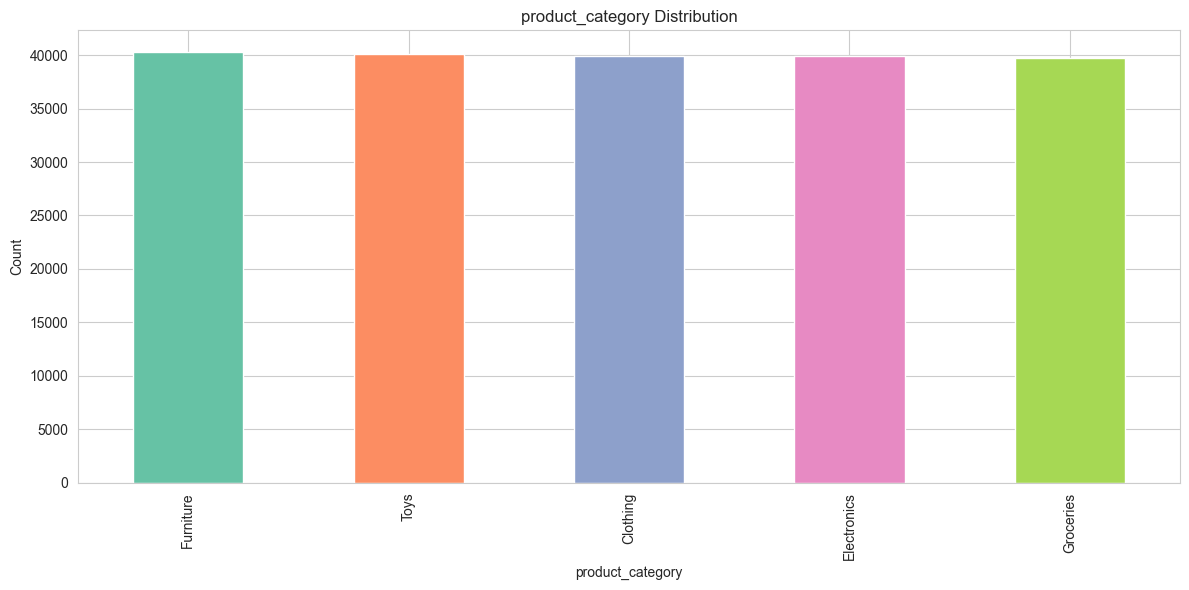

In [ ]:
# Product category distribution
cat_cols = [c for c in df.columns if 'category' in c.lower()]
if cat_cols:
    for col in cat_cols:
        fig, ax = plt.subplots(figsize=(12, 6))
        df[col].value_counts().plot(kind='bar', ax=ax, color=sns.color_palette('Set2'))
        ax.set_title(f'{col} Distribution')
        ax.set_ylabel('Count')
        plt.tight_layout()
        plt.show()


## 4. Sales & Revenue Analysis

In [ ]:
sales_cols = [c for c in df.columns if any(k in c.lower() for k in ['price', 'sales', 'revenue', 'cost', 'amount', 'total', 'profit', 'discount'])]
print('Sales-related columns:', sales_cols)

num_sales = [c for c in sales_cols if df[c].dtype in ['float64', 'int64']]
if num_sales:
    n = min(len(num_sales), 6)
    fig, axes = plt.subplots((n+1)//2, 2, figsize=(16, 4*((n+1)//2)))
    axes = axes.flatten()
    for i, col in enumerate(num_sales[:n]):
        axes[i].hist(df[col].dropna(), bins=50, edgecolor='black', alpha=0.7)
        axes[i].set_title(f'{col} (mean={df[col].mean():.2f})')
        axes[i].axvline(df[col].mean(), color='red', linestyle='--')
    for j in range(i+1, len(axes)):
        axes[j].set_visible(False)
    plt.tight_layout()
    plt.show()


## 5. Customer Analysis

In [ ]:
cust_cols = [c for c in df.columns if any(k in c.lower() for k in ['customer', 'user', 'client', 'loyalty', 'churn', 'age', 'gender', 'income'])]
print('Customer-related columns:', cust_cols)

# Demographics
demo_cols = [c for c in cust_cols if df[c].nunique() < 20]
if demo_cols:
    n = min(len(demo_cols), 6)
    fig, axes = plt.subplots((n+1)//2, 2, figsize=(16, 4*((n+1)//2)))
    axes = axes.flatten()
    for i, col in enumerate(demo_cols[:n]):
        df[col].value_counts().plot(kind='bar', ax=axes[i], color=sns.color_palette('pastel'))
        axes[i].set_title(col)
    for j in range(i+1, len(axes)):
        axes[j].set_visible(False)
    plt.tight_layout()
    plt.show()


## 6. Temporal Analysis

In [ ]:
date_cols = [c for c in df.columns if 'date' in c.lower() or 'time' in c.lower()]
print('Date columns:', date_cols)

for col in date_cols[:2]:  # first 2 date cols
    try:
        dt = pd.to_datetime(df[col], errors='coerce')
        if dt.notna().sum() > 0:
            print(f'\n{col}: {dt.min()} to {dt.max()}')
            fig, axes = plt.subplots(1, 2, figsize=(16, 5))
            dt.dt.dayofweek.value_counts().sort_index().plot(kind='bar', ax=axes[0], color='steelblue')
            axes[0].set_title(f'{col} — Day of Week')
            dt.dt.month.value_counts().sort_index().plot(kind='bar', ax=axes[1], color='coral')
            axes[1].set_title(f'{col} — Month')
            plt.tight_layout()
            plt.show()
    except Exception as e:
        print(f'{col}: could not parse — {e}')


## 7. Shelf-Relevant Features

In [ ]:
shelf_cols = [c for c in df.columns if any(k in c.lower() for k in ['shelf', 'stock', 'store', 'location', 'promo', 'rating'])]
print('Shelf/store-relevant columns:', shelf_cols)

for col in shelf_cols:
    if df[col].nunique() <= 20:
        print(f'\n{col}:')
        print(df[col].value_counts())
    else:
        print(f'\n{col}: {df[col].nunique()} unique — Mean: {df[col].mean():.2f}' if df[col].dtype in ['float64','int64'] else f'\n{col}: {df[col].nunique()} unique')


## 8. Correlation Matrix (Key Numeric Columns)

In [ ]:
key_num = [c for c in df.select_dtypes(include=[np.number]).columns if any(k in c.lower() for k in ['price','sales','quantity','revenue','cost','discount','profit','rating','stock','age','income','loyalty'])]
if len(key_num) > 2:
    fig, ax = plt.subplots(figsize=(14, 12))
    sns.heatmap(df[key_num].corr(), annot=True, fmt='.2f', cmap='coolwarm', ax=ax, center=0)
    ax.set_title('Correlation Matrix — Key Business Metrics')
    plt.tight_layout()
    plt.show()


## 9. Relevance to Shelf Optimization / Planogram AI

**Strengths (78 columns!):**
- Product shelf life, stock levels, ratings — direct shelf management features
- Promotion data (type, channel, effectiveness) — promo shelf placement
- Customer demographics & loyalty — localized planogram potential
- Sales, revenue, cost, discount — full margin analysis
- Store location data — multi-store optimization

**Limitations:**
- Analysis on 200k sample — full 1M may reveal more patterns
- Likely synthetic data (too clean, no nulls)
- No physical shelf layout or aisle mapping


## 10. RFM Customer Segmentation Analysis

RFM (Recency, Frequency, Monetary) analysis is a proven customer segmentation technique that helps identify high-value customers and those at risk of churning.

- **Recency (R)**: How recently did the customer make a purchase? (`days_since_last_purchase`)
- **Frequency (F)**: How often do they purchase? (`total_transactions`)
- **Monetary (M)**: How much do they spend? (`total_sales`)

In [ ]:
# RFM Score Calculation
# Create customer-level RFM metrics (aggregate if needed - but each row appears to be customer-level)
rfm_df = df[['customer_id', 'days_since_last_purchase', 'total_transactions', 'total_sales', 'churned']].copy()
rfm_df = rfm_df.drop_duplicates(subset='customer_id')
print(f'Unique customers for RFM analysis: {len(rfm_df):,}')

# Create RFM scores (1-5 scale using quintiles)
# Recency: Lower is better (inverted scoring)
rfm_df['R_Score'] = pd.qcut(rfm_df['days_since_last_purchase'], q=5, labels=[5, 4, 3, 2, 1], duplicates='drop')
# Frequency: Higher is better
rfm_df['F_Score'] = pd.qcut(rfm_df['total_transactions'], q=5, labels=[1, 2, 3, 4, 5], duplicates='drop')
# Monetary: Higher is better
rfm_df['M_Score'] = pd.qcut(rfm_df['total_sales'], q=5, labels=[1, 2, 3, 4, 5], duplicates='drop')

# Convert to int for calculations
rfm_df['R_Score'] = rfm_df['R_Score'].astype(int)
rfm_df['F_Score'] = rfm_df['F_Score'].astype(int)
rfm_df['M_Score'] = rfm_df['M_Score'].astype(int)

# Create combined RFM score and segment string
rfm_df['RFM_Score'] = rfm_df['R_Score'] + rfm_df['F_Score'] + rfm_df['M_Score']
rfm_df['RFM_Segment'] = rfm_df['R_Score'].astype(str) + rfm_df['F_Score'].astype(str) + rfm_df['M_Score'].astype(str)

print('\nRFM Score Distribution:')
print(rfm_df[['R_Score', 'F_Score', 'M_Score', 'RFM_Score']].describe())

# Visualize RFM score distributions
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for i, (col, title) in enumerate([('R_Score', 'Recency Score'), ('F_Score', 'Frequency Score'), 
                                    ('M_Score', 'Monetary Score'), ('RFM_Score', 'Combined RFM Score')]):
    rfm_df[col].value_counts().sort_index().plot(kind='bar', ax=axes[i], color=sns.color_palette('viridis', 5) if i < 3 else 'steelblue')
    axes[i].set_title(title)
    axes[i].set_xlabel('Score')
    axes[i].set_ylabel('Count')
plt.tight_layout()
plt.show()

In [ ]:
# Define customer segments based on RFM scores
def segment_customer(row):
    r, f, m = row['R_Score'], row['F_Score'], row['M_Score']
    
    if r >= 4 and f >= 4 and m >= 4:
        return 'Champions'
    elif r >= 4 and f >= 3 and m >= 3:
        return 'Loyal Customers'
    elif r >= 4 and f <= 2:
        return 'Recent Customers'
    elif r >= 3 and f >= 3 and m >= 3:
        return 'Potential Loyalists'
    elif r >= 3 and f >= 1 and m >= 4:
        return 'Big Spenders'
    elif r == 2 and f >= 3:
        return 'At Risk'
    elif r == 2 and f <= 2:
        return 'Hibernating'
    elif r == 1 and f >= 3 and m >= 3:
        return 'Cant Lose Them'
    elif r == 1 and f <= 2:
        return 'Lost'
    else:
        return 'Others'

rfm_df['Segment'] = rfm_df.apply(segment_customer, axis=1)

# Segment distribution
segment_counts = rfm_df['Segment'].value_counts()
segment_pct = (segment_counts / len(rfm_df) * 100).round(2)

print('Customer Segment Distribution:')
segment_summary = pd.DataFrame({'Count': segment_counts, 'Percentage': segment_pct})
print(segment_summary)

# Visualize segment distribution
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Pie chart
colors = sns.color_palette('Set2', len(segment_counts))
axes[0].pie(segment_counts.values, labels=segment_counts.index, autopct='%1.1f%%', colors=colors, startangle=90)
axes[0].set_title('Customer Segments Distribution')

# Bar chart
segment_counts.plot(kind='barh', ax=axes[1], color=colors)
axes[1].set_xlabel('Number of Customers')
axes[1].set_title('Customer Segments by Count')
for i, v in enumerate(segment_counts.values):
    axes[1].text(v + 100, i, f'{v:,} ({segment_pct.iloc[i]}%)', va='center')

plt.tight_layout()
plt.show()

### 10.1 K-Means Clustering on RFM Features

Using machine learning to identify natural customer clusters based on RFM characteristics.

In [ ]:
# Prepare data for K-Means clustering
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Select RFM features for clustering
X = rfm_df[['days_since_last_purchase', 'total_transactions', 'total_sales']].values

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Determine optimal k using elbow method and silhouette score
k_range = range(2, 11)
inertias = []
silhouette_scores = []

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, kmeans.labels_))

# Plot elbow method and silhouette scores
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(k_range, inertias, 'bo-', linewidth=2, markersize=8)
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Inertia (Within-cluster Sum of Squares)')
axes[0].set_title('Elbow Method for Optimal k')
axes[0].grid(True)

axes[1].plot(k_range, silhouette_scores, 'go-', linewidth=2, markersize=8)
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score vs Number of Clusters')
axes[1].grid(True)

plt.tight_layout()
plt.show()

# Best k based on silhouette
best_k = k_range[np.argmax(silhouette_scores)]
print(f'\nOptimal k based on silhouette score: {best_k}')
print(f'Best silhouette score: {max(silhouette_scores):.4f}')

In [ ]:
# Apply K-Means with optimal k (use 5 for business interpretability or best_k)
optimal_k = 5  # Using 5 for alignment with RFM quintiles
kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
rfm_df['Cluster'] = kmeans_final.fit_predict(X_scaled)

# Profile each cluster
cluster_profile = rfm_df.groupby('Cluster').agg({
    'days_since_last_purchase': 'mean',
    'total_transactions': 'mean',
    'total_sales': 'mean',
    'R_Score': 'mean',
    'F_Score': 'mean',
    'M_Score': 'mean',
    'RFM_Score': 'mean',
    'customer_id': 'count'
}).rename(columns={'customer_id': 'Count'})

cluster_profile['Pct'] = (cluster_profile['Count'] / len(rfm_df) * 100).round(2)

# Name clusters based on characteristics
cluster_names = {}
for cluster in range(optimal_k):
    profile = cluster_profile.loc[cluster]
    r_avg, f_avg, m_avg = profile['R_Score'], profile['F_Score'], profile['M_Score']
    
    if r_avg >= 3.5 and f_avg >= 3.5 and m_avg >= 3.5:
        cluster_names[cluster] = 'Premium Customers'
    elif r_avg >= 3 and f_avg >= 3:
        cluster_names[cluster] = 'Growing Customers'
    elif r_avg <= 2 and f_avg >= 3:
        cluster_names[cluster] = 'At Risk - High Value'
    elif r_avg <= 2 and f_avg <= 2:
        cluster_names[cluster] = 'Churning/Lost'
    elif m_avg >= 3.5:
        cluster_names[cluster] = 'High Spenders'
    else:
        cluster_names[cluster] = f'Cluster {cluster}'

rfm_df['Cluster_Name'] = rfm_df['Cluster'].map(cluster_names)
cluster_profile['Cluster_Name'] = cluster_profile.index.map(cluster_names)

print('K-Means Cluster Profiles:')
print(cluster_profile.round(2))

# Visualize cluster characteristics
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Cluster sizes
cluster_profile['Count'].plot(kind='bar', ax=axes[0, 0], color=sns.color_palette('Set2', optimal_k))
axes[0, 0].set_title('Cluster Sizes')
axes[0, 0].set_xlabel('Cluster')
axes[0, 0].set_ylabel('Customer Count')
axes[0, 0].tick_params(axis='x', rotation=0)

# Average RFM by cluster
cluster_profile[['R_Score', 'F_Score', 'M_Score']].plot(kind='bar', ax=axes[0, 1])
axes[0, 1].set_title('Average RFM Scores by Cluster')
axes[0, 1].set_xlabel('Cluster')
axes[0, 1].legend(title='Score Type')
axes[0, 1].tick_params(axis='x', rotation=0)

# Monetary value by cluster
cluster_profile['total_sales'].plot(kind='bar', ax=axes[1, 0], color='coral')
axes[1, 0].set_title('Average Total Sales by Cluster')
axes[1, 0].set_xlabel('Cluster')
axes[1, 0].set_ylabel('Avg Total Sales ($)')
axes[1, 0].tick_params(axis='x', rotation=0)

# 3D scatter of clusters (projected to 2D using first two dimensions)
scatter = axes[1, 1].scatter(X_scaled[:, 0], X_scaled[:, 2], c=rfm_df['Cluster'], cmap='Set2', alpha=0.5, s=10)
axes[1, 1].set_xlabel('Recency (Standardized)')
axes[1, 1].set_ylabel('Monetary (Standardized)')
axes[1, 1].set_title('Customer Clusters (Recency vs Monetary)')
plt.colorbar(scatter, ax=axes[1, 1], label='Cluster')

plt.tight_layout()
plt.show()

### 10.2 Churn Analysis by Segment

Analyzing churn rates across different RFM segments to identify high-value customers at risk.

In [ ]:
# Convert churned to binary
rfm_df['churned_binary'] = (rfm_df['churned'] == 'Yes').astype(int)

# Churn rate by RFM segment
churn_by_segment = rfm_df.groupby('Segment').agg({
    'churned_binary': ['sum', 'mean', 'count'],
    'total_sales': 'sum'
}).round(4)
churn_by_segment.columns = ['Churned_Count', 'Churn_Rate', 'Total_Customers', 'Total_Revenue']
churn_by_segment['Churn_Rate_Pct'] = (churn_by_segment['Churn_Rate'] * 100).round(2)
churn_by_segment['Revenue_At_Risk'] = (churn_by_segment['Churn_Rate'] * churn_by_segment['Total_Revenue']).round(2)
churn_by_segment = churn_by_segment.sort_values('Churn_Rate', ascending=False)

print('Churn Analysis by RFM Segment:')
print(churn_by_segment)

# Visualize churn by segment
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Churn rate by segment
churn_by_segment['Churn_Rate_Pct'].plot(kind='barh', ax=axes[0, 0], color='crimson')
axes[0, 0].set_xlabel('Churn Rate (%)')
axes[0, 0].set_title('Churn Rate by Customer Segment')
axes[0, 0].axvline(x=rfm_df['churned_binary'].mean()*100, color='black', linestyle='--', label='Overall Avg')
axes[0, 0].legend()

# Churned vs retained by segment
churn_counts = rfm_df.groupby(['Segment', 'churned']).size().unstack(fill_value=0)
churn_counts.plot(kind='bar', stacked=True, ax=axes[0, 1], color=['green', 'red'])
axes[0, 1].set_title('Churned vs Retained by Segment')
axes[0, 1].set_xlabel('Segment')
axes[0, 1].set_ylabel('Customer Count')
axes[0, 1].tick_params(axis='x', rotation=45)
axes[0, 1].legend(title='Churned')

# Revenue at risk by segment
churn_by_segment['Revenue_At_Risk'].sort_values().plot(kind='barh', ax=axes[1, 0], color='orange')
axes[1, 0].set_xlabel('Revenue at Risk ($)')
axes[1, 0].set_title('Revenue at Risk by Segment')

# Churn rate by RFM score
churn_by_rfm = rfm_df.groupby('RFM_Score')['churned_binary'].mean() * 100
churn_by_rfm.plot(kind='line', marker='o', ax=axes[1, 1], color='purple', linewidth=2)
axes[1, 1].set_xlabel('RFM Score')
axes[1, 1].set_ylabel('Churn Rate (%)')
axes[1, 1].set_title('Churn Rate by Combined RFM Score')
axes[1, 1].grid(True)

plt.tight_layout()
plt.show()

# Overall churn statistics
print(f'\nOverall Churn Rate: {rfm_df["churned_binary"].mean()*100:.2f}%')
print(f'Total Churned Customers: {rfm_df["churned_binary"].sum():,}')

In [ ]:
# Identify high-value at-risk customers
# High value: top 25% by total_sales, At risk: churned=No but low recency score
high_value_threshold = rfm_df['total_sales'].quantile(0.75)

rfm_df['high_value'] = rfm_df['total_sales'] >= high_value_threshold
rfm_df['at_risk'] = (rfm_df['R_Score'] <= 2) & (rfm_df['churned'] == 'No')
rfm_df['high_value_at_risk'] = rfm_df['high_value'] & rfm_df['at_risk']

# Summary of high-value at-risk customers
hvar_customers = rfm_df[rfm_df['high_value_at_risk']]
print(f'High-Value At-Risk Customers:')
print(f'  Count: {len(hvar_customers):,} ({len(hvar_customers)/len(rfm_df)*100:.2f}% of all customers)')
print(f'  Total Revenue: ${hvar_customers["total_sales"].sum():,.2f}')
print(f'  Avg Revenue per Customer: ${hvar_customers["total_sales"].mean():,.2f}')
print(f'  Avg Days Since Last Purchase: {hvar_customers["days_since_last_purchase"].mean():.1f}')

# Profile comparison
comparison = pd.DataFrame({
    'All Customers': rfm_df[['total_sales', 'total_transactions', 'days_since_last_purchase']].mean(),
    'High-Value At-Risk': hvar_customers[['total_sales', 'total_transactions', 'days_since_last_purchase']].mean(),
    'Champions': rfm_df[rfm_df['Segment']=='Champions'][['total_sales', 'total_transactions', 'days_since_last_purchase']].mean()
})
print('\nProfile Comparison:')
print(comparison.round(2))

# Visualize high-value at-risk distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter: total_sales vs days_since_last_purchase highlighting HVAR
colors = rfm_df['high_value_at_risk'].map({True: 'red', False: 'lightgray'})
axes[0].scatter(rfm_df['days_since_last_purchase'], rfm_df['total_sales'], c=colors, alpha=0.5, s=10)
axes[0].axhline(y=high_value_threshold, color='blue', linestyle='--', label=f'High Value Threshold (${high_value_threshold:,.0f})')
axes[0].set_xlabel('Days Since Last Purchase')
axes[0].set_ylabel('Total Sales ($)')
axes[0].set_title('High-Value At-Risk Customers (Red)')
axes[0].legend()

# Distribution of HVAR by segment
hvar_by_segment = rfm_df.groupby('Segment')['high_value_at_risk'].sum().sort_values(ascending=False)
hvar_by_segment.plot(kind='bar', ax=axes[1], color='firebrick')
axes[1].set_title('High-Value At-Risk Customers by Segment')
axes[1].set_xlabel('Segment')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

### 10.3 Customer Lifetime Value (CLV) Analysis

Calculating and analyzing Customer Lifetime Value by segment.

In [ ]:
# Merge additional columns needed for CLV calculation
clv_cols = ['customer_id', 'avg_purchase_value', 'avg_transaction_value', 'membership_years']
clv_data = df[clv_cols].drop_duplicates(subset='customer_id')
rfm_df = rfm_df.merge(clv_data, on='customer_id', how='left')

# Simple CLV calculation
# CLV = Average Purchase Value x Purchase Frequency x Customer Lifespan
# Using: avg_transaction_value x total_transactions x (membership_years or estimated lifespan)

# Estimate annual purchase frequency
days_in_data = 365 * 2  # 2 years of data based on transaction dates
rfm_df['annual_frequency'] = rfm_df['total_transactions'] / (days_in_data / 365)

# Calculate simple CLV (project 3 years forward)
projection_years = 3
rfm_df['CLV_simple'] = rfm_df['avg_transaction_value'] * rfm_df['annual_frequency'] * projection_years

# Alternative: Use total_sales as historical CLV proxy
rfm_df['CLV_historical'] = rfm_df['total_sales']

print('CLV Statistics:')
print(rfm_df[['CLV_simple', 'CLV_historical', 'total_sales']].describe().round(2))

# CLV by segment
clv_by_segment = rfm_df.groupby('Segment').agg({
    'CLV_simple': ['mean', 'median', 'sum'],
    'CLV_historical': ['mean', 'sum'],
    'customer_id': 'count'
}).round(2)
clv_by_segment.columns = ['CLV_Mean', 'CLV_Median', 'CLV_Total', 'Historical_CLV_Mean', 'Historical_CLV_Total', 'Count']
clv_by_segment = clv_by_segment.sort_values('CLV_Mean', ascending=False)

print('\nCLV by Segment:')
print(clv_by_segment)

# Visualize CLV distribution
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# CLV distribution
axes[0, 0].hist(rfm_df['CLV_simple'].clip(upper=rfm_df['CLV_simple'].quantile(0.99)), bins=50, edgecolor='black', alpha=0.7)
axes[0, 0].set_xlabel('CLV (3-year projection)')
axes[0, 0].set_ylabel('Customer Count')
axes[0, 0].set_title('CLV Distribution (Capped at 99th percentile)')
axes[0, 0].axvline(rfm_df['CLV_simple'].mean(), color='red', linestyle='--', label=f'Mean: ${rfm_df["CLV_simple"].mean():,.0f}')
axes[0, 0].legend()

# Average CLV by segment
clv_by_segment['CLV_Mean'].plot(kind='barh', ax=axes[0, 1], color=sns.color_palette('viridis', len(clv_by_segment)))
axes[0, 1].set_xlabel('Average CLV ($)')
axes[0, 1].set_title('Average CLV by Customer Segment')

# Total CLV by segment (segment value)
clv_by_segment['CLV_Total'].plot(kind='barh', ax=axes[1, 0], color='teal')
axes[1, 0].set_xlabel('Total CLV ($)')
axes[1, 0].set_title('Total Segment Value (CLV)')

# CLV vs Churn Rate
clv_churn = rfm_df.groupby('Segment').agg({
    'CLV_simple': 'mean',
    'churned_binary': 'mean'
})
axes[1, 1].scatter(clv_churn['CLV_simple'], clv_churn['churned_binary']*100, s=100, c='purple', alpha=0.7)
for segment, row in clv_churn.iterrows():
    axes[1, 1].annotate(segment, (row['CLV_simple'], row['churned_binary']*100), fontsize=8, ha='center')
axes[1, 1].set_xlabel('Average CLV ($)')
axes[1, 1].set_ylabel('Churn Rate (%)')
axes[1, 1].set_title('CLV vs Churn Rate by Segment')
axes[1, 1].grid(True)

plt.tight_layout()
plt.show()

### 10.4 Segment Profiles & Business Recommendations

Detailed profiles for each customer segment with actionable recommendations.

In [ ]:
# Comprehensive segment profiles
segment_profiles = rfm_df.groupby('Segment').agg({
    'customer_id': 'count',
    'days_since_last_purchase': 'mean',
    'total_transactions': 'mean',
    'total_sales': ['mean', 'sum'],
    'CLV_simple': 'mean',
    'churned_binary': 'mean',
    'R_Score': 'mean',
    'F_Score': 'mean',
    'M_Score': 'mean'
}).round(2)

segment_profiles.columns = ['Count', 'Avg_Recency', 'Avg_Transactions', 'Avg_Sales', 'Total_Sales', 
                            'Avg_CLV', 'Churn_Rate', 'Avg_R', 'Avg_F', 'Avg_M']
segment_profiles['Pct_of_Customers'] = (segment_profiles['Count'] / len(rfm_df) * 100).round(2)
segment_profiles['Pct_of_Revenue'] = (segment_profiles['Total_Sales'] / rfm_df['total_sales'].sum() * 100).round(2)

# Define recommendations for each segment
recommendations = {
    'Champions': 'Reward with exclusive perks, early access to new products. Use for testimonials/referrals.',
    'Loyal Customers': 'Upsell premium products, loyalty program upgrades. Personalized recommendations.',
    'Recent Customers': 'Welcome campaigns, onboarding sequences. Build engagement early.',
    'Potential Loyalists': 'Engagement campaigns, membership benefits. Convert to loyal customers.',
    'Big Spenders': 'Premium product offers, VIP treatment. Focus on increasing purchase frequency.',
    'At Risk': 'Win-back campaigns, personalized offers. Understand pain points via surveys.',
    'Hibernating': 'Reactivation campaigns with strong incentives. Limited-time offers.',
    'Cant Lose Them': 'URGENT: Personalized outreach, special discounts. Understand why they left.',
    'Lost': 'Aggressive win-back campaigns or accept churn. Survey to understand reasons.',
    'Others': 'Standard marketing campaigns. Monitor for segment movement.'
}

segment_profiles['Recommendation'] = segment_profiles.index.map(recommendations)

print('Segment Profiles Summary:')
display_cols = ['Count', 'Pct_of_Customers', 'Pct_of_Revenue', 'Avg_Sales', 'Avg_CLV', 'Churn_Rate']
print(segment_profiles[display_cols].sort_values('Pct_of_Revenue', ascending=False))

print('\n\nDetailed Recommendations:')
for segment in segment_profiles.index:
    profile = segment_profiles.loc[segment]
    print(f'\n--- {segment} ---')
    print(f'  Customers: {profile["Count"]:,.0f} ({profile["Pct_of_Customers"]}%)')
    print(f'  Revenue Share: {profile["Pct_of_Revenue"]}%')
    print(f'  Avg CLV: ${profile["Avg_CLV"]:,.2f}')
    print(f'  Churn Rate: {profile["Churn_Rate"]*100:.2f}%')
    print(f'  Recommendation: {profile["Recommendation"]}')

In [ ]:
# Visualize segment value vs size
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bubble chart: Customer % vs Revenue % (bubble = avg CLV)
segments = segment_profiles.index.tolist()
x = segment_profiles['Pct_of_Customers'].values
y = segment_profiles['Pct_of_Revenue'].values
sizes = (segment_profiles['Avg_CLV'] / segment_profiles['Avg_CLV'].max() * 500).values

scatter = axes[0].scatter(x, y, s=sizes, alpha=0.6, c=range(len(segments)), cmap='Set2')
axes[0].plot([0, max(x)*1.1], [0, max(x)*1.1], 'k--', alpha=0.3, label='Equal share line')
for i, segment in enumerate(segments):
    axes[0].annotate(segment, (x[i], y[i]), fontsize=9, ha='center', va='bottom')
axes[0].set_xlabel('% of Customers')
axes[0].set_ylabel('% of Revenue')
axes[0].set_title('Segment Value: Customer Share vs Revenue Share\n(Bubble size = Avg CLV)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Heatmap of segment characteristics
heatmap_data = segment_profiles[['Avg_R', 'Avg_F', 'Avg_M', 'Churn_Rate']].copy()
heatmap_data['Churn_Rate'] = heatmap_data['Churn_Rate'] * 100
heatmap_data = heatmap_data.rename(columns={'Churn_Rate': 'Churn%'})
sns.heatmap(heatmap_data, annot=True, fmt='.1f', cmap='RdYlGn', ax=axes[1], center=3)
axes[1].set_title('Segment Characteristics Heatmap')
axes[1].set_xlabel('')

plt.tight_layout()
plt.show()

### 10.5 Demographics by Segment

Analyzing demographic distributions (age, income, loyalty status) and channel preferences across segments.

In [ ]:
# Merge demographic columns
demo_cols = ['customer_id', 'age', 'income_bracket', 'loyalty_program', 'gender', 
             'online_purchases', 'in_store_purchases']
demo_data = df[demo_cols].drop_duplicates(subset='customer_id')
rfm_df = rfm_df.merge(demo_data, on='customer_id', how='left')

# Calculate online vs in-store preference
rfm_df['total_channel_purchases'] = rfm_df['online_purchases'] + rfm_df['in_store_purchases']
rfm_df['online_pct'] = (rfm_df['online_purchases'] / rfm_df['total_channel_purchases'] * 100).fillna(50)
rfm_df['channel_preference'] = pd.cut(rfm_df['online_pct'], 
                                       bins=[-1, 33, 66, 101], 
                                       labels=['In-Store Focused', 'Omnichannel', 'Online Focused'])

# Demographics by segment
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# Age distribution by segment
age_by_segment = rfm_df.groupby('Segment')['age'].mean().sort_values()
age_by_segment.plot(kind='barh', ax=axes[0, 0], color='steelblue')
axes[0, 0].set_xlabel('Average Age')
axes[0, 0].set_title('Average Age by Segment')
axes[0, 0].axvline(rfm_df['age'].mean(), color='red', linestyle='--', label=f'Overall: {rfm_df["age"].mean():.1f}')
axes[0, 0].legend()

# Income distribution by segment
income_segment = pd.crosstab(rfm_df['Segment'], rfm_df['income_bracket'], normalize='index') * 100
income_segment.plot(kind='bar', stacked=True, ax=axes[0, 1], colormap='RdYlGn')
axes[0, 1].set_title('Income Bracket Distribution by Segment')
axes[0, 1].set_ylabel('Percentage')
axes[0, 1].tick_params(axis='x', rotation=45)
axes[0, 1].legend(title='Income', bbox_to_anchor=(1.02, 1))

# Loyalty program by segment
loyalty_segment = pd.crosstab(rfm_df['Segment'], rfm_df['loyalty_program'], normalize='index') * 100
loyalty_segment.plot(kind='bar', ax=axes[0, 2], color=['salmon', 'seagreen'])
axes[0, 2].set_title('Loyalty Program Membership by Segment')
axes[0, 2].set_ylabel('Percentage')
axes[0, 2].tick_params(axis='x', rotation=45)
axes[0, 2].legend(title='Loyalty Member')

# Gender distribution by segment
gender_segment = pd.crosstab(rfm_df['Segment'], rfm_df['gender'], normalize='index') * 100
gender_segment.plot(kind='bar', stacked=True, ax=axes[1, 0], colormap='Set2')
axes[1, 0].set_title('Gender Distribution by Segment')
axes[1, 0].set_ylabel('Percentage')
axes[1, 0].tick_params(axis='x', rotation=45)
axes[1, 0].legend(title='Gender')

# Channel preference by segment
channel_segment = pd.crosstab(rfm_df['Segment'], rfm_df['channel_preference'], normalize='index') * 100
channel_segment.plot(kind='bar', stacked=True, ax=axes[1, 1], colormap='coolwarm')
axes[1, 1].set_title('Channel Preference by Segment')
axes[1, 1].set_ylabel('Percentage')
axes[1, 1].tick_params(axis='x', rotation=45)
axes[1, 1].legend(title='Channel', bbox_to_anchor=(1.02, 1))

# Online purchase percentage by segment
online_by_segment = rfm_df.groupby('Segment')['online_pct'].mean().sort_values()
online_by_segment.plot(kind='barh', ax=axes[1, 2], color='purple')
axes[1, 2].set_xlabel('Online Purchase %')
axes[1, 2].set_title('Online Purchase Share by Segment')
axes[1, 2].axvline(50, color='gray', linestyle='--', label='50% threshold')
axes[1, 2].legend()

plt.tight_layout()
plt.show()

In [ ]:
# Detailed demographic summary by segment
demo_summary = rfm_df.groupby('Segment').agg({
    'age': 'mean',
    'online_pct': 'mean',
    'loyalty_program': lambda x: (x == 'Yes').mean() * 100
}).round(2)
demo_summary.columns = ['Avg_Age', 'Online_Pct', 'Loyalty_Member_Pct']

# Add income breakdown
for income in rfm_df['income_bracket'].unique():
    demo_summary[f'Income_{income}_Pct'] = rfm_df.groupby('Segment').apply(
        lambda x: (x['income_bracket'] == income).mean() * 100
    ).round(2)

print('Demographic Summary by Segment:')
print(demo_summary.sort_values('Avg_Age'))

# Key insights
print('\n\nKey Demographic Insights:')
print('='*60)
youngest_segment = demo_summary['Avg_Age'].idxmin()
oldest_segment = demo_summary['Avg_Age'].idxmax()
most_online = demo_summary['Online_Pct'].idxmax()
most_loyal = demo_summary['Loyalty_Member_Pct'].idxmax()

print(f'Youngest segment: {youngest_segment} (avg age {demo_summary.loc[youngest_segment, "Avg_Age"]:.1f})')
print(f'Oldest segment: {oldest_segment} (avg age {demo_summary.loc[oldest_segment, "Avg_Age"]:.1f})')
print(f'Most online-focused: {most_online} ({demo_summary.loc[most_online, "Online_Pct"]:.1f}% online)')
print(f'Highest loyalty membership: {most_loyal} ({demo_summary.loc[most_loyal, "Loyalty_Member_Pct"]:.1f}%)')

### 10.6 RFM Segmentation Summary

Key takeaways from the RFM customer segmentation analysis.

In [ ]:
# Final summary statistics
print('='*70)
print('RFM CUSTOMER SEGMENTATION SUMMARY')
print('='*70)

print(f'\nTotal Customers Analyzed: {len(rfm_df):,}')
print(f'Total Revenue: ${rfm_df["total_sales"].sum():,.2f}')
print(f'Average CLV (3-yr projection): ${rfm_df["CLV_simple"].mean():,.2f}')
print(f'Overall Churn Rate: {rfm_df["churned_binary"].mean()*100:.2f}%')

print('\n--- SEGMENT SUMMARY ---')
summary_table = segment_profiles[['Count', 'Pct_of_Customers', 'Pct_of_Revenue', 'Churn_Rate']].copy()
summary_table['Churn_Rate'] = (summary_table['Churn_Rate'] * 100).round(2)
summary_table = summary_table.sort_values('Pct_of_Revenue', ascending=False)
print(summary_table.to_string())

print('\n--- HIGH-VALUE AT-RISK CUSTOMERS ---')
print(f'Count: {len(hvar_customers):,}')
print(f'Revenue at risk: ${hvar_customers["total_sales"].sum():,.2f}')
print(f'Priority action: Immediate win-back campaigns')

print('\n--- K-MEANS CLUSTERS ---')
print(f'Optimal clusters: {optimal_k}')
print('Cluster distribution:')
print(rfm_df['Cluster_Name'].value_counts().to_string())

print('\n--- TOP RECOMMENDATIONS ---')
print('1. Champions: Leverage for referrals and testimonials')
print('2. At-Risk/Cant Lose Them: Urgent retention campaigns')
print('3. Lost/Hibernating: Evaluate cost-benefit of win-back')
print('4. Potential Loyalists: Focus on conversion to loyal')
print('5. Recent Customers: Strong onboarding and engagement')